# Malaria Cases in the United States - Exploratory Data Analysis
### State and County-Level Distribution | 2016 vs. 2017

**Author:** Dr. Maria Julia Judson, DVM, MSc  
**Data Source:** CDC - Number of Reported Malaria Cases by County, United States (2016 & 2017)  
**Tools:** Python (pandas, matplotlib, numpy), Power BI.

---

## Project Overview

Malaria cases reported in the United States are almost exclusively travel-associated, making their geographic distribution a reflection of international travel patterns and access to healthcare. This analysis uses CDC county-level surveillance data to identify which states and counties reported the highest malaria burden in 2016 and 2017, and quantifies year-over-year changes in reported cases.

**Objectives:**
1. Identify states and counties with the highest reported malaria burden;
2. Compare disease distribution between 2016 and 2017;
3. Quantify absolute and relative year-over-year changes at the state and county level;
4. Flag data quality considerations (missing states/counties across years).

---
## 1. Setup & Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

---
## 2. Load & Prepare Data

In [3]:
# Load raw CDC datasets
df2016 = pd.read_csv("Number_of_Reported_Malaria_Cases_by_County—_United_States,_2016_20260508.csv")
df2017 = pd.read_csv("Number_of_Reported_Malaria_Cases_by_County—_United_States,_2017_20260508.csv")

# Standardize case column names and add year
df2016 = df2016.rename(columns={"MAL_FREQ_2016": "cases"})
df2017 = df2017.rename(columns={"MAL_FREQ_2017": "cases"})
df2016["year"] = 2016
df2017["year"] = 2017

# Combine into single dataset
combined = pd.concat([df2016, df2017], ignore_index=True)

print(f"2016: {df2016.shape[0]} positive county records | {df2016['STATE'].nunique()} states")
print(f"2017: {df2017.shape[0]} positive county records | {df2017['STATE'].nunique()} states")
print(f"Combined: {combined.shape[0]} positive county records")

2016: 98 positive county records | 32 states
2017: 97 positive county records | 29 states
Combined: 195 positive county records


---
## 3. Data Quality - Coverage Check

Before comparing years, we verify which states appear in both datasets. States present in only one year are excluded from year-over-year comparisons to avoid misleading results.

In [4]:
states_2016 = set(df2016["STATE"].dropna())
states_2017 = set(df2017["STATE"].dropna())

missing_in_2017 = states_2016 - states_2017
missing_in_2016 = states_2017 - states_2016
common_states = states_2016.intersection(states_2017)

print(f"States in 2016 only: {missing_in_2017 or 'None'}")
print(f"States in 2017 only: {missing_in_2016 or 'None'}")
print(f"States present in both years: {len(common_states)}")

# Positive counties only
positive_2016 = df2016[df2016["cases"] > 0]
positive_2017 = df2017[df2017["cases"] > 0]
print(f"\nCounties with ≥1 case — 2016: {len(positive_2016)} | 2017: {len(positive_2017)}")

States in 2016 only: {'CALIFORNIA', 'VERMONT', 'WISCONSIN', 'TENNESSEE', 'NEVADA', 'DELAWARE', 'KENTUCKY'}
States in 2017 only: {'NORTH DAKOTA', 'SOUTH DAKOTA', 'WASHINGTON', 'IOWA'}
States present in both years: 25

Counties with ≥1 case — 2016: 98 | 2017: 97


---
## 4. State-Level Analysis

In [5]:
# Aggregate by state and year — common states only
summary_state = combined.groupby(["STATE", "year"])["cases"].sum().reset_index()
summary_state_filtered = summary_state[summary_state["STATE"].isin(common_states)]

# Pivot for side-by-side comparison
state_pivot = summary_state_filtered.pivot_table(
    index="STATE", columns="year", values="cases", fill_value=0
).reset_index()

# Year-over-year metrics
state_pivot["change"] = state_pivot[2017] - state_pivot[2016]
state_pivot["pct_change"] = np.where(
    state_pivot[2016] == 0,
    np.where(state_pivot[2017] > 0, np.inf, 0),
    ((state_pivot[2017] - state_pivot[2016]) / state_pivot[2016]) * 100
)

print(f"Total cases 2016: {state_pivot[2016].sum():,.0f}")
print(f"Total cases 2017: {state_pivot[2017].sum():,.0f}")
print(f"National change:  {state_pivot['change'].sum():+,.0f} cases")

Total cases 2016: 1,273
Total cases 2017: 1,370
National change:  +97 cases


### Top 10 States - 2016 vs. 2017

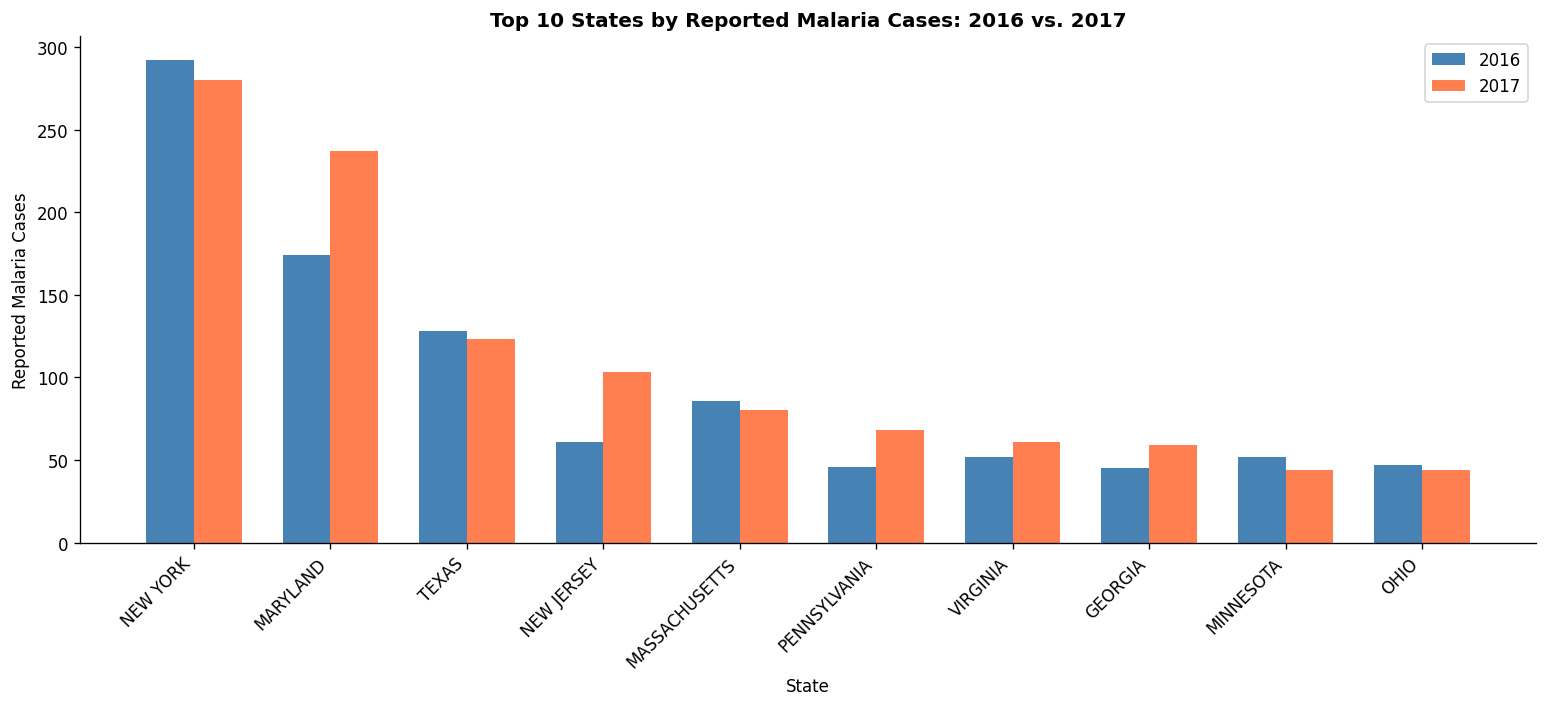

In [6]:
top10_states = state_pivot.sort_values(by=2017, ascending=False).head(10)

x = np.arange(len(top10_states))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 6))

ax.bar(x - width/2, top10_states[2016], width, label="2016", color="steelblue")
ax.bar(x + width/2, top10_states[2017], width, label="2017", color="coral")

ax.set_xticks(x)
ax.set_xticklabels(top10_states["STATE"], rotation=45, ha="right")
ax.set_xlabel("State")
ax.set_ylabel("Reported Malaria Cases")
ax.set_title("Top 10 States by Reported Malaria Cases: 2016 vs. 2017", fontweight="bold")
ax.legend()

plt.tight_layout()
plt.show()

**Observation:** New York leads all states with 280 cases in 2017, followed by Maryland (237) and Texas (123). Together, these three states account for nearly half of all reported cases nationally, consistent with their roles as major international travel and immigration hubs. Maryland stands out as the state with the largest absolute increase among the top 10 (+63 cases), while New York saw a modest decline (−12), suggesting shifting travel patterns or reporting differences between years.

### Year-over-Year Change by State (Absolute)

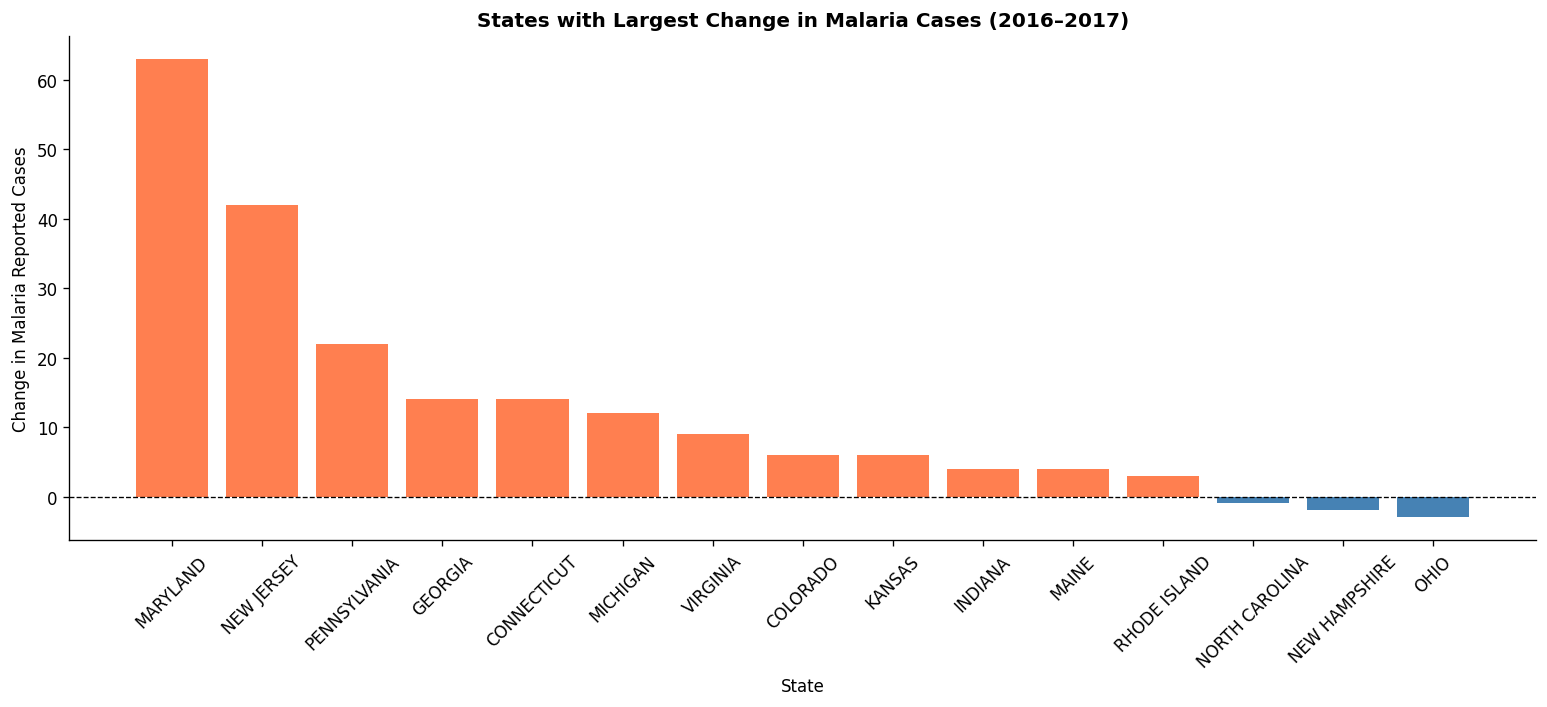

In [7]:
change_sorted = state_pivot.sort_values(by="change", ascending=False).head(15)

colors = ["coral" if c > 0 else "steelblue" for c in change_sorted["change"]]

fig, ax = plt.subplots(figsize=(13, 6))

ax.bar(change_sorted["STATE"], change_sorted["change"], color=colors)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")

ax.set_xlabel("State")
ax.set_ylabel("Change in Malaria Reported Cases")
ax.set_title("States with Largest Change in Malaria Cases (2016–2017)", fontweight="bold")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

**Observation:** Maryland (+63) and New Jersey (+42) recorded the largest absolute increases from 2016 to 2017, together accounting for over half of the national net gain of 97 cases. Connecticut, despite its smaller baseline (8 cases in 2016), more than doubled its count to 22, a modest absolute shift that nonetheless signals notable growth. No state showed a steep absolute decline; the largest drops were in New York (−12) and Minnesota (−8), likely reflecting year-to-year variability in travel volume rather than a sustained downward trend.

### Year-over-Year Change by State (Relative %)

Percentage change highlights states with significant relative increases, even if their absolute numbers are small. States with 0 cases in 2016 and >0 in 2017 are flagged separately as new reporters.

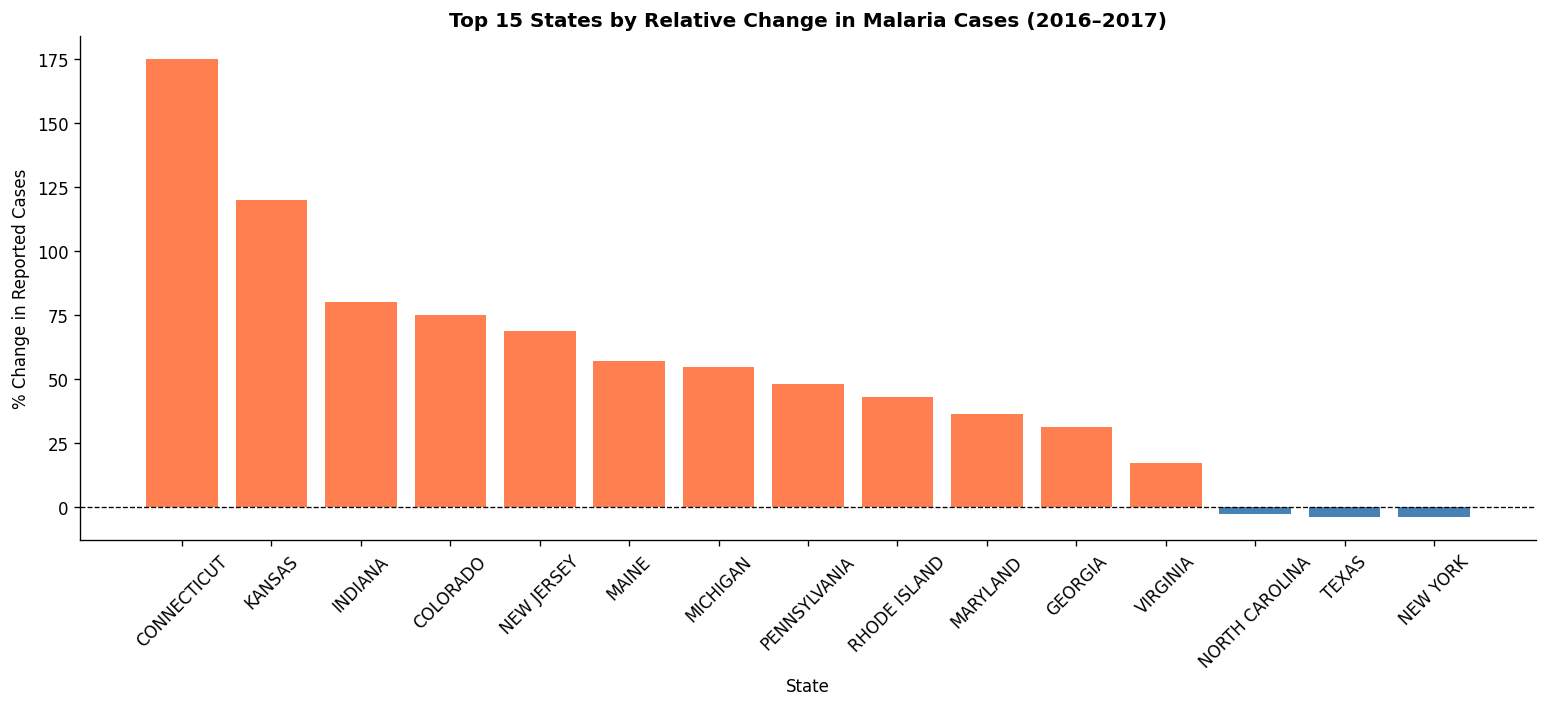

In [ ]:
# Exclude infinite values (new reporters) for cleaner chart
pct_finite = state_pivot[state_pivot["pct_change"] != np.inf].sort_values(
    by="pct_change", ascending=False
).head(15)

new_reporters = state_pivot[state_pivot["pct_change"] == np.inf]

colors = ["coral" if p > 0 else "steelblue" for p in pct_finite["pct_change"]]

fig, ax = plt.subplots(figsize=(13, 6))

ax.bar(pct_finite["STATE"], pct_finite["pct_change"], color=colors)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")

ax.set_xlabel("State")
ax.set_ylabel("% Change in Reported Cases")
ax.set_title("Top 15 States by Relative Change in Malaria Cases (2016–2017)", fontweight="bold")
ax.tick_params(axis="x", rotation=45)

if not new_reporters.empty:
    states_list = ", ".join(new_reporters["STATE"].tolist())
    ax.annotate(f"New reporters (0→1+ cases): {states_list}",
                xy=(0.01, 0.97), xycoords="axes fraction",
                fontsize=8, color="gray", va="top")

plt.tight_layout()
plt.show()

**Observation:** The state of  Connecticut recorded the greatest relative increase among all states, with a 175% rise (8 → 22 cases), followed by Kansas (+120%) and Indiana (+80%). These figures warrant careful interpretation, as states with low baseline counts are inherently more susceptible to large percentage fluctuations, a shift from 5 to 11 cases yields +120%, yet represents only 6 additional cases in absolute terms. Conversely, traditionally high-burden states such as New York and Texas experienced marginal reductions (−4% each), indicating that the national net gain of +97 cases was largely attributable to increases across mid-tier states rather than the principal reporting jurisdictions. Notably, no new reporting states emerged in 2017 — all states with recorded cases had also reported in 2016.

---
## 5. County-Level Analysis

In [ ]:
# Aggregate by county
summary_county = combined.groupby(["STATE", "COUNTY", "FIPS", "year"])["cases"].sum().reset_index()

county_pivot = summary_county.pivot_table(
    index=["STATE", "COUNTY", "FIPS"],
    columns="year",
    values="cases",
    fill_value=0
).reset_index()

county_pivot["change"] = county_pivot[2017] - county_pivot[2016]

### Top US 10 Counties - 2016 vs. 2017

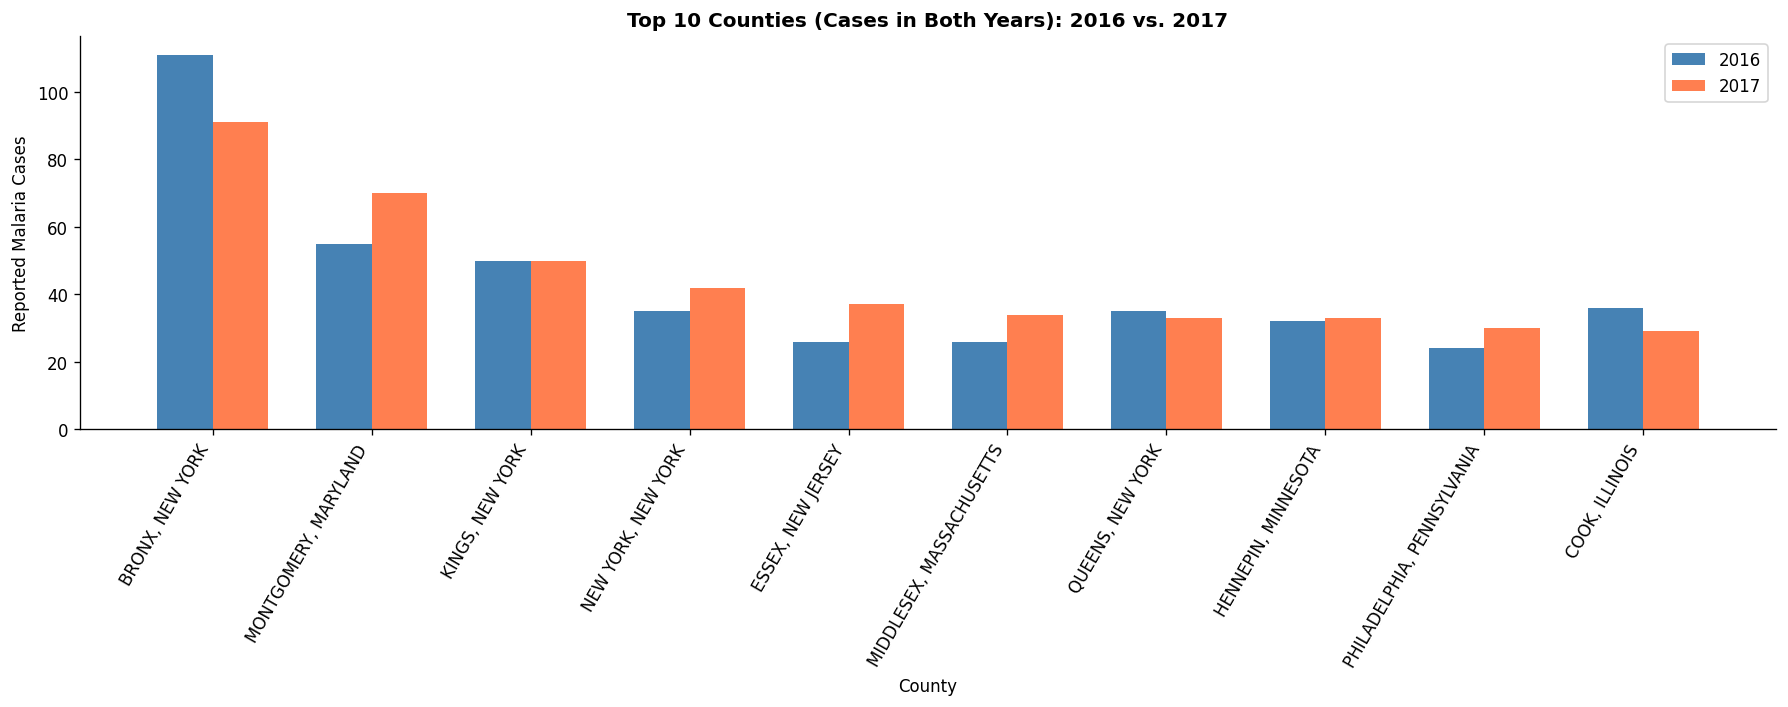

In [ ]:
filtered_county_pivot = county_pivot[(county_pivot[2016] > 0) & (county_pivot[2017] > 0)]
top10_counties = filtered_county_pivot.sort_values(by=2017, ascending=False).head(10)
county_labels = top10_counties["COUNTY"] + ", " + top10_counties["STATE"]

x = np.arange(len(top10_counties))
width = 0.35

fig, ax = plt.subplots(figsize=(15, 6))

ax.bar(x - width/2, top10_counties[2016], width, label="2016", color="steelblue")
ax.bar(x + width/2, top10_counties[2017], width, label="2017", color="coral")

ax.set_xticks(x)
ax.set_xticklabels(county_labels, rotation=60, ha="right")
ax.set_xlabel("County")
ax.set_ylabel("Reported Malaria Cases")
ax.set_title("Top 10 Counties (Cases in Both Years): 2016 vs. 2017", fontweight="bold")
ax.legend()

plt.tight_layout()
plt.show()

**Observation:** The Bronx, NY leads all counties with 91 cases in 2017, down from 111 in 2016, yet still accounting for roughly a third of New York State's total burden on its own. Montgomery County, MD recorded the largest county-level increase (+15 cases), consistent with Maryland's state-level growth. Four of the top 10 counties are in New York State (Bronx, Kings, New York, Queens), highlighting extreme intra-state concentration,  a pattern shown where a state's aggregate burden is often driven by a small number of hotspot counties. All top-10 counties are in major metropolitan areas, reinforcing the travel-associated nature of U.S. malaria cases.

---
## 6. Key Insights

| # | Finding |
|---|--------|
| 1 | **Concentrated burden:** New York (280 cases), Maryland (237), and Texas (123) account for the vast majority of U.S. malaria cases, reflecting geographic clustering around major urban and international travel hubs. |
| 2 | **Year-over-year shift:** Maryland (+63) and New Jersey (+42) drove most of the national net gain of +97 cases, while Connecticut (+175%), Kansas (+120%), and Indiana (+80%) recorded the largest relative increases despite low baselines, reinforcing that growing burden is not exclusive to the highest-volume states. |
| 3 | **County-level concentration:** Within high-burden states, cases concentrate heavily in one or two counties. Four of the top 10 counties nationally are in New York State alone (Bronx, Kings, New York, Queens), with the Bronx leading at 91 cases in 2017. |
| 4 | **Data coverage gaps:** Not all states appear in both years, which limits direct year-over-year comparisons. Analysis was restricted to common states to ensure comparability. |
| 5 | **Travel-associated context:** U.S. malaria cases are almost exclusively imported. Geographic patterns, concentrated in states like New York, Maryland, and Texas, likely reflect international travel routes, immigration corridors, and access to diagnostic services rather than local transmission. |

---